In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

fpath = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/DATA/checks/bns_snr_8_50_uniform_4096Hz_100K_5s/test/sig_combined_test.h5'
f = h5py.File(fpath, 'r')

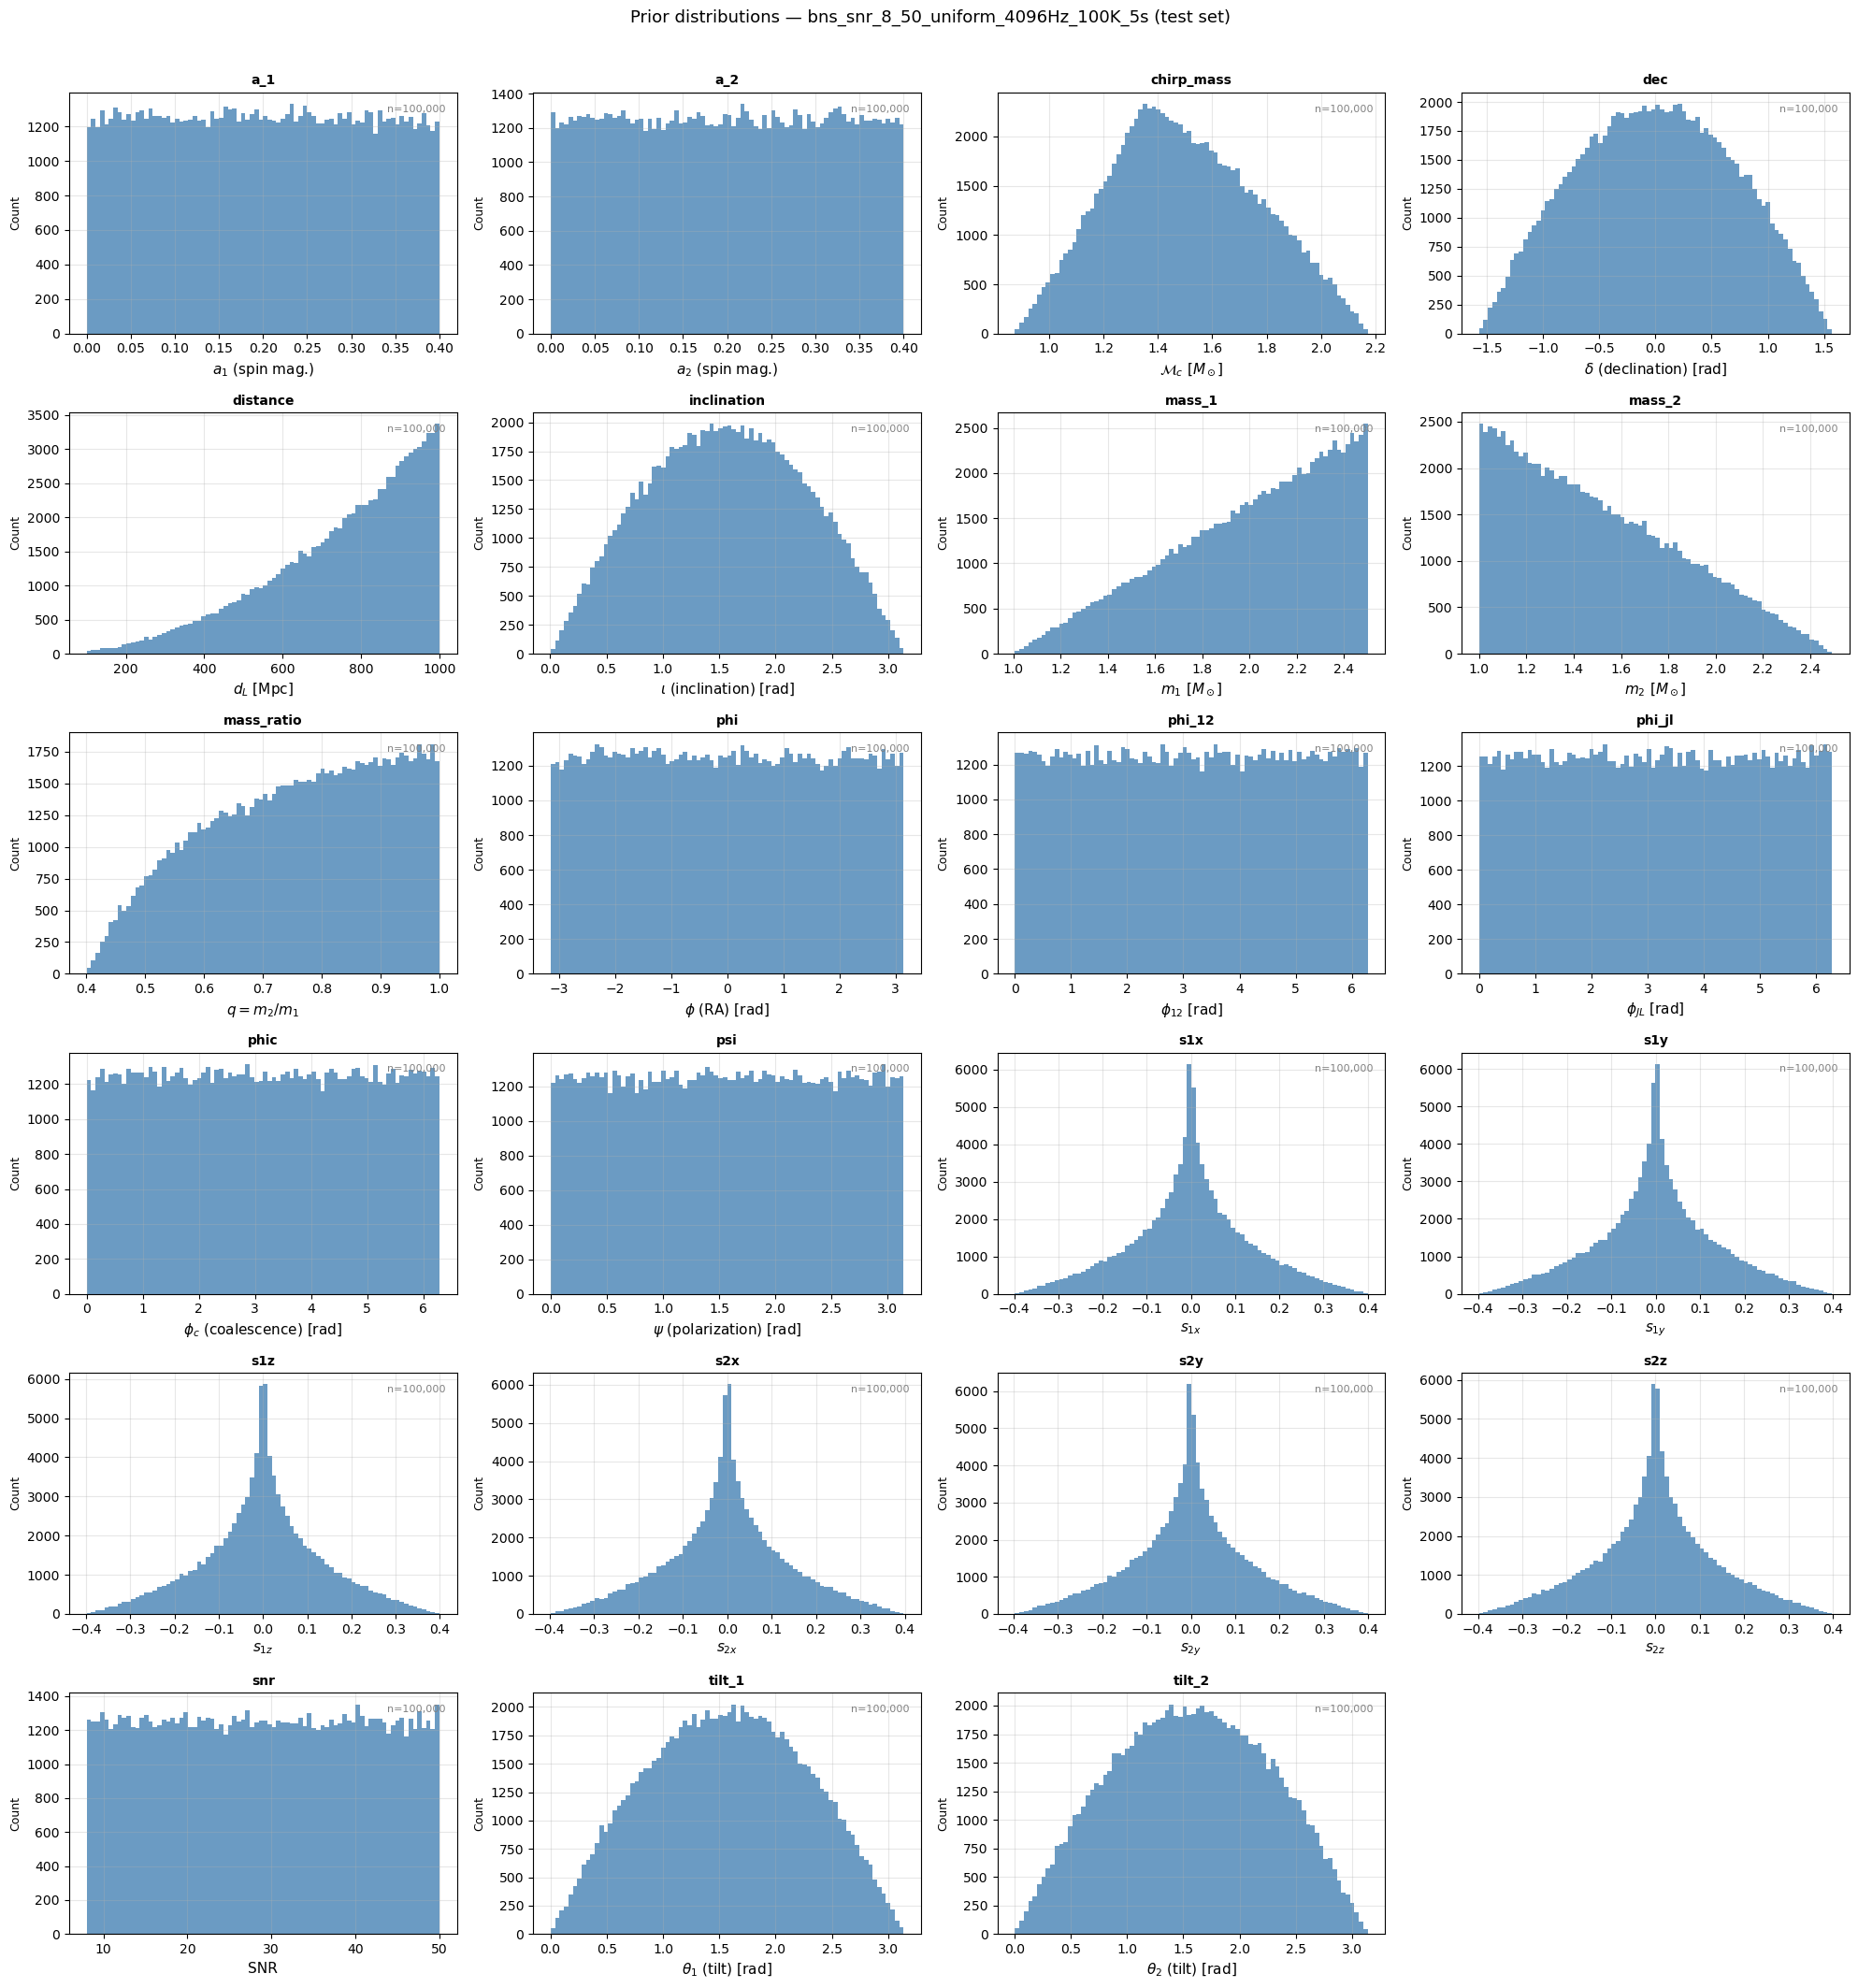

: 

In [ ]:
SKIP = {'whitened_bkg', 'whitened_injected', 'whitened_signal'}

params = sorted([k for k in f.keys() if k not in SKIP])

LABELS = {
    'a_1':        r'$a_1$ (spin mag.)',
    'a_2':        r'$a_2$ (spin mag.)',
    'chirp_mass': r'$\mathcal{M}_c\ [M_\odot]$',
    'dec':        r'$\delta$ (declination) [rad]',
    'distance':   r'$d_L$ [Mpc]',
    'inclination':r'$\iota$ (inclination) [rad]',
    'mass_1':     r'$m_1\ [M_\odot]$',
    'mass_2':     r'$m_2\ [M_\odot]$',
    'mass_ratio': r'$q = m_2/m_1$',
    'phi':        r'$\phi$ (RA) [rad]',
    'phi_12':     r'$\phi_{12}$ [rad]',
    'phi_jl':     r'$\phi_{JL}$ [rad]',
    'phic':       r'$\phi_c$ (coalescence) [rad]',
    'psi':        r'$\psi$ (polarization) [rad]',
    's1x':        r'$s_{1x}$',
    's1y':        r'$s_{1y}$',
    's1z':        r'$s_{1z}$',
    's2x':        r'$s_{2x}$',
    's2y':        r'$s_{2y}$',
    's2z':        r'$s_{2z}$',
    'snr':        r'SNR',
    'tilt_1':     r'$\theta_1$ (tilt) [rad]',
    'tilt_2':     r'$\theta_2$ (tilt) [rad]',
}

ncols = 4
nrows = int(np.ceil(len(params) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for ax, key in zip(axes, params):
    data = f[key][:]
    ax.hist(data, bins=80, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_xlabel(LABELS.get(key, key), fontsize=11)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(key, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.95, f'n={len(data):,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

for ax in axes[len(params):]:
    ax.set_visible(False)

plt.suptitle(
    'Prior distributions — bns_snr_8_50_uniform_4096Hz_100K_5s (test set)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('prior_distributions.png', dpi=150, bbox_inches='tight')
plt.show()